# Final NLP Data Exploration: Balanced Emotion and Sentiment

This notebook checks the balanced dataset produced by `src/balance_dataset.py`. It summarizes the input-to-output cleanup, verifies that the **emotion** and **sentiment** marginal distributions are equal, and visualizes the final counts.

**Label note:** the six emotion classes are the existing dataset labels. Sentiment values in the source were assigned by a simple lexicon heuristic, not manually verified. Treat sentiment-model results as agreement with those estimated labels.


In [2]:
from pathlib import Path
import json
import pandas as pd
import matplotlib.pyplot as plt

# Works when launched from the project root or from src/.
PROJECT_ROOT = Path.cwd()
if not (PROJECT_ROOT / "data" / "final.csv").exists():
    PROJECT_ROOT = PROJECT_ROOT.parent
DATA_PATH = PROJECT_ROOT / "data" / "final.csv"
SUMMARY_PATH = PROJECT_ROOT / "data" / "balancing_summary.json"
df = pd.read_csv(DATA_PATH)
summary = json.loads(SUMMARY_PATH.read_text())
print(f"Loaded {len(df):,} rows from {DATA_PATH}")
print("Columns:", df.columns.tolist())
print("Rows in source:", f"{summary['input_rows']:,}")
print("Rows in final dataset:", f"{summary['rows_after_balance']:,}")
print("Rows removed during cleanup and undersampling:", f"{summary['input_rows'] - summary['rows_after_balance']:,}")
print("Synthetic emoji rows cleaned:", f"{summary['synthetic_emoji_rows_cleaned']:,}")
print("Conflicting duplicate-text groups removed:", f"{summary['conflicting_text_groups_removed']:,}")
print("Exact duplicate rows removed:", f"{summary['same_label_duplicate_rows_removed']:,}")

Loaded 58,980 rows from /Users/rohitgurung/Desktop/NLP/data/final.csv
Columns: ['source_index', 'text', 'label', 'emotion', 'sentiment']
Rows in source: 416,809
Rows in final dataset: 58,980
Rows removed during cleanup and undersampling: 357,829
Synthetic emoji rows cleaned: 44,650
Conflicting duplicate-text groups removed: 22,295
Exact duplicate rows removed: 632


In [3]:
emotion_counts = df["emotion"].value_counts().sort_index()
sentiment_counts = df["sentiment"].value_counts().sort_index()
print("Emotion counts:")
print(emotion_counts.to_string())
print("\nSentiment counts:")
print(sentiment_counts.to_string())

# Both marginal targets must have identical counts across their classes.
assert emotion_counts.nunique() == 1
assert sentiment_counts.nunique() == 1
print("\nPASS: emotion and sentiment classes are exactly balanced.")

Emotion counts:
emotion
anger       9830
fear        9830
joy         9830
love        9830
sadness     9830
surprise    9830

Sentiment counts:
sentiment
negative    19660
neutral     19660
positive    19660

PASS: emotion and sentiment classes are exactly balanced.


## Class balance plots

Both target columns have equal counts per class in `final.csv`.

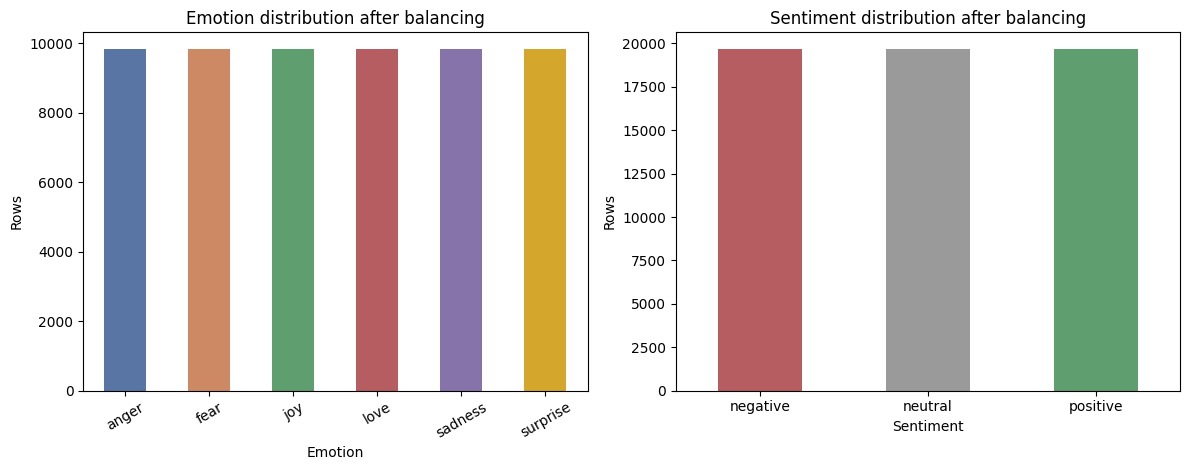

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.8))
emotion_counts.plot(kind="bar", ax=axes[0], color=["#5975a4", "#cc8963", "#5f9e6e", "#b55d60", "#8573a9", "#d4a72c"])
axes[0].set_title("Emotion distribution after balancing")
axes[0].set_xlabel("Emotion")
axes[0].set_ylabel("Rows")
axes[0].tick_params(axis="x", rotation=30)
sentiment_counts.reindex(["negative", "neutral", "positive"]).plot(kind="bar", ax=axes[1], color=["#b55d60", "#9a9a9a", "#5f9e6e"])
axes[1].set_title("Sentiment distribution after balancing")
axes[1].set_xlabel("Sentiment")
axes[1].set_ylabel("Rows")
axes[1].tick_params(axis="x", rotation=0)
fig.tight_layout()
plt.show()

In [6]:
joint_counts = pd.crosstab(df["sentiment"], df["emotion"]).reindex(["negative", "neutral", "positive"])
print("Sentiment × emotion counts (the individual class totals are balanced):")
print(joint_counts.to_string())
print("\nText rows with missing values:", int(df[["text", "label", "emotion", "sentiment"]].isna().any(axis=1).sum()))
print("Duplicate text rows:", int(df["text"].duplicated().sum()))
print("Emotion ID mapping:", {0: "sadness", 1: "joy", 2: "love", 3: "anger", 4: "fear", 5: "surprise"})

Sentiment × emotion counts (the individual class totals are balanced):
emotion    anger  fear   joy  love  sadness  surprise
sentiment                                            
negative    3469  6095  5020  1341     3126       609
neutral     6361     0     0  5493        0      7806
positive       0  3735  4810  2996     6704      1415

Text rows with missing values: 0
Duplicate text rows: 0
Emotion ID mapping: {0: 'sadness', 1: 'joy', 2: 'love', 3: 'anger', 4: 'fear', 5: 'surprise'}


## Balancing and modeling notes

- `final.csv` was created with seeded undersampling and contains no repeated text examples.
- Rows with label-coded synthetic emoji suffixes were restored to their text-only form before use. Text groups with conflicting emotion or sentiment labels were removed.
- Both targets are balanced **marginally**. Some emotion–sentiment pairs have no source examples, so the joint table is not uniform.
- This file is appropriate for training and exploration. For a trustworthy test score, use a held-out set created before balancing and review the heuristic sentiment labels.
